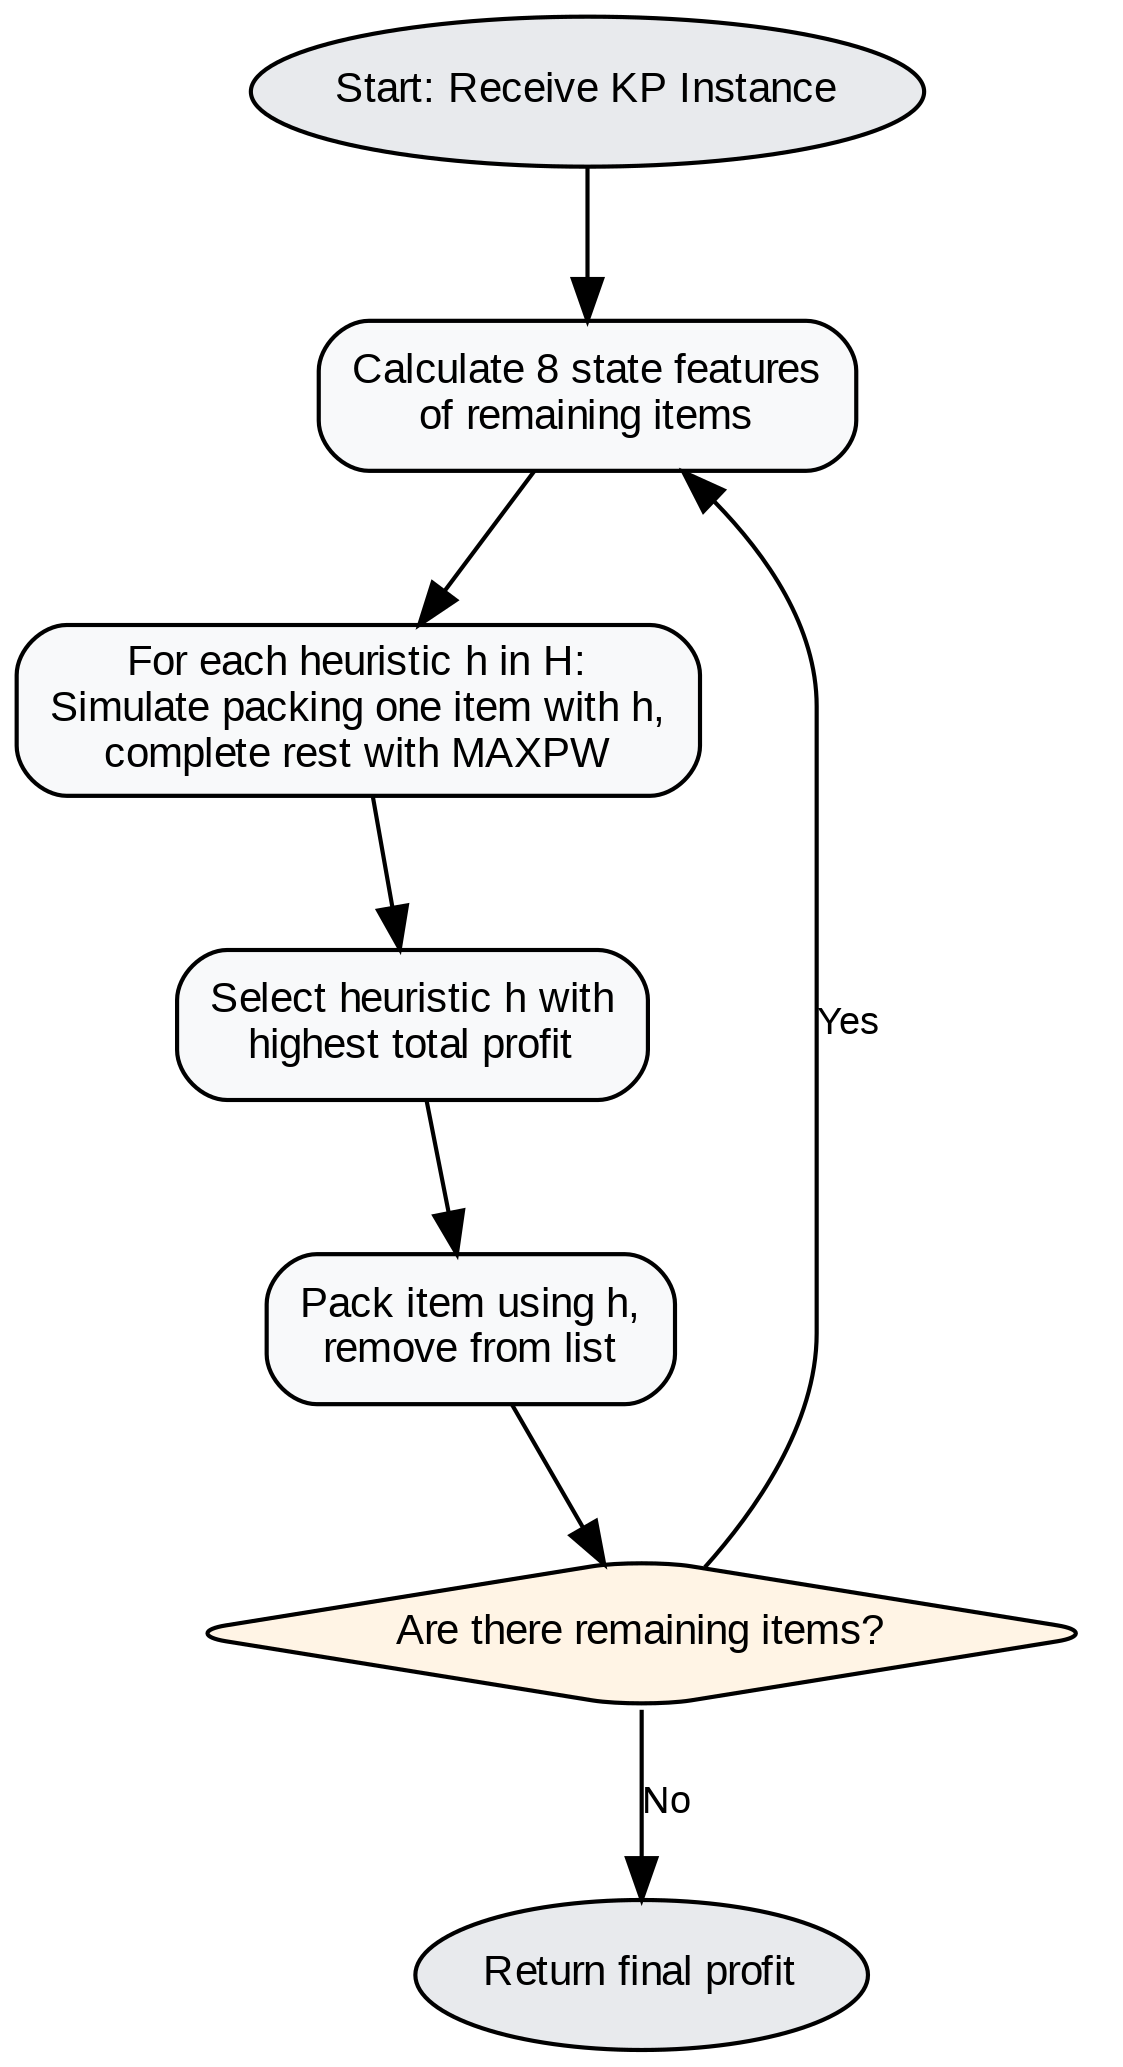

In [2]:
import graphviz
from IPython.display import Image

# Create a new directed graph
dot = graphviz.Digraph(comment='Knapsack Method Flowchart')

# Set graph attributes for a professional look
dot.attr(dpi='300')
dot.attr('node', shape='rectangle', style='rounded,filled', fillcolor='#F8F9FA', fontname='Arial', fontsize='10')
dot.attr('edge', fontname='Arial', fontsize='9')

# Step 1: Start
dot.node('START', 'Start: Receive KP Instance', shape='ellipse', fillcolor='#E8EAED')

# Step 2: Calculate features
dot.node('STEP2', 'Calculate 8 state features\nof remaining items')

# Step 3: Simulation loop
dot.node('STEP3', 'For each heuristic h in H:\nSimulate packing one item with h,\ncomplete rest with MAXPW')

# Step 4: Selection
dot.node('STEP4', 'Select heuristic h with\nhighest total profit')

# Step 5: Action
dot.node('STEP5', 'Pack item using h,\nremove from list')

# Step 6: Decision
dot.node('DECISION', 'Are there remaining items?', shape='diamond', fillcolor='#FFF4E5')

# Step 7: Final result
dot.node('END', 'Return final profit', shape='ellipse', fillcolor='#E8EAED')

# Define edges (connections)
dot.edge('START', 'STEP2')
dot.edge('STEP2', 'STEP3')
dot.edge('STEP3', 'STEP4')
dot.edge('STEP4', 'STEP5')
dot.edge('STEP5', 'DECISION')
dot.edge('DECISION', 'STEP2', label='Yes')
dot.edge('DECISION', 'END', label='No')

# Render and save the diagram
dot.render('flowchart', format='png', cleanup=True)

# Display the result
Image('flowchart.png')

Diagrama guardado exitosamente como flowchart.png (300 DPI, tight).


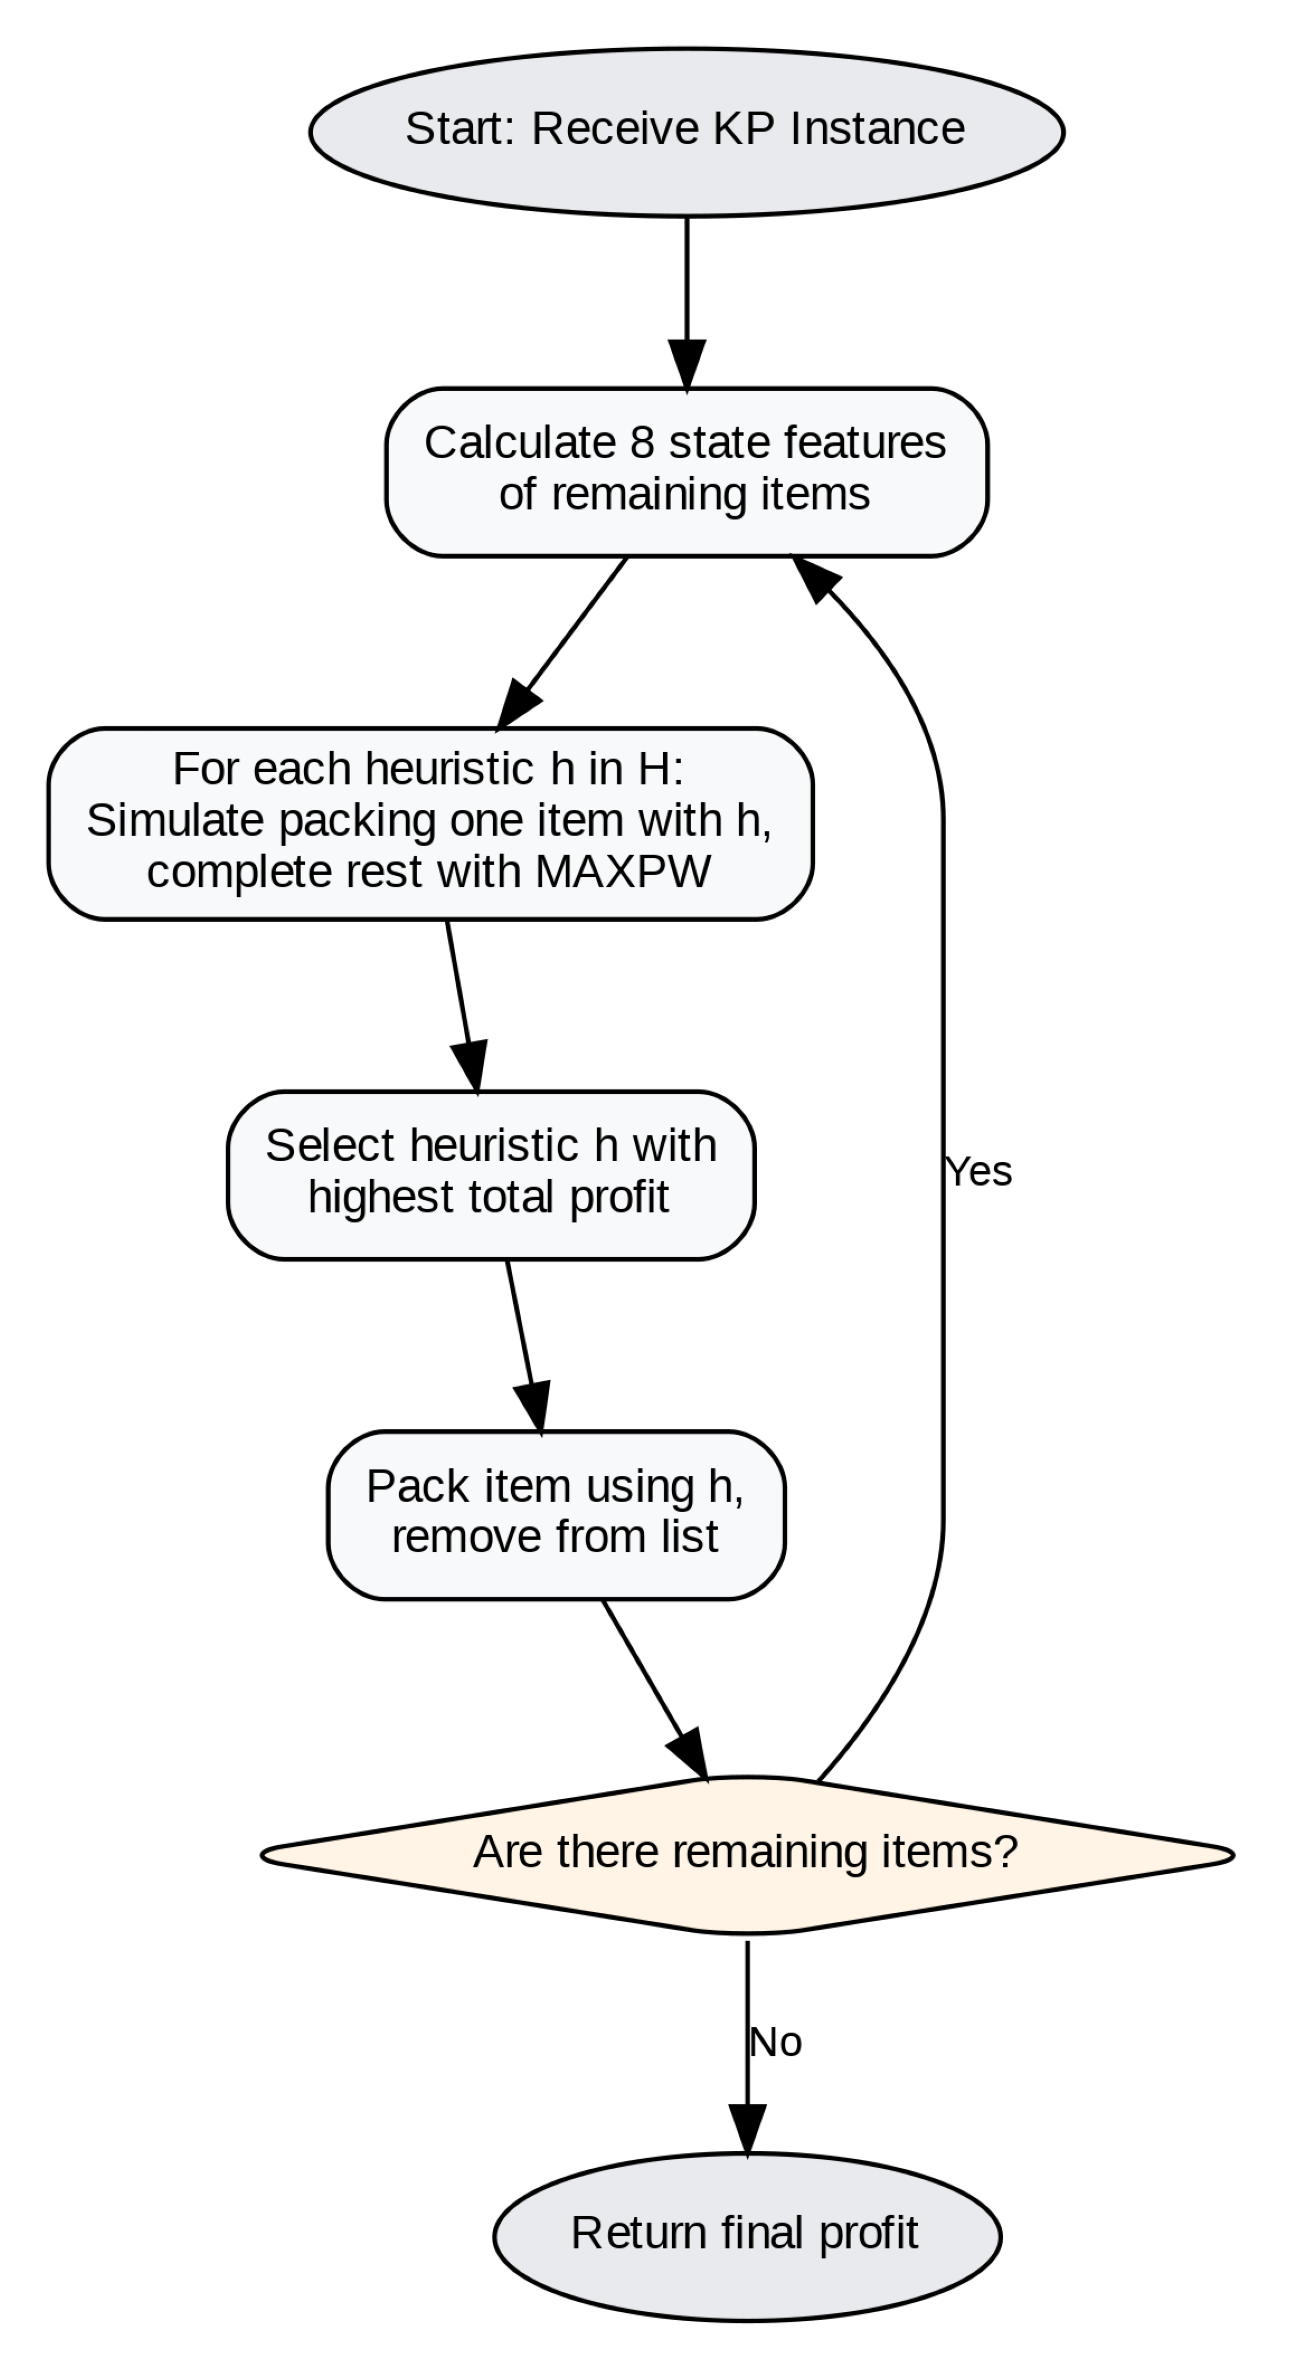

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# El diagrama ya fue renderizado por graphviz en la celda anterior.
# Para cumplir con tu petición de usar plt.savefig a 300 DPI:
img = mpimg.imread('flowchart.png')

plt.figure(figsize=(10, 10), dpi=300)
plt.imshow(img)
plt.axis('off')

# Guardar con los parámetros específicos solicitados
plt.savefig('flowchart.png', dpi=300, bbox_inches='tight')
print('Diagrama guardado exitosamente como flowchart.png (300 DPI, tight).')
plt.show()

In [3]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Define target directory in Drive
drive_path = '/content/drive/MyDrive/Colab_Exports'
os.makedirs(drive_path, exist_ok=True)

# Copy the file
!cp /content/flowchart.png {drive_path}/flowchart.png

print(f"File successfully exported to: {drive_path}/flowchart.png")

Mounted at /content/drive
File successfully exported to: /content/drive/MyDrive/Colab_Exports/flowchart.png


### Verificación y Descarga Directa
Si no encuentras el archivo en la interfaz de Google Drive, usa el siguiente código para confirmar su existencia en la ruta o descargarlo directamente.

In [9]:
import os
from google.colab import files

# 1. Verificar si el archivo existe en la ruta de Drive
drive_full_path = '/content/drive/MyDrive/Colab_Exports/flowchart.png'
if os.path.exists(drive_full_path):
    print(f'✅ El archivo existe en Drive: {drive_full_path}')
else:
    print('❌ El archivo NO se encuentra en la carpeta de Drive. Intentando descarga local...')

# 2. Descarga directa (del archivo temporal generado en Colab)
if os.path.exists('flowchart.png'):
    print('Iniciando descarga de flowchart.png...')
    files.download('flowchart.png')
else:
    print('Error: El archivo original no fue encontrado en el entorno local.')

❌ El archivo NO se encuentra en la carpeta de Drive. Intentando descarga local...
Iniciando descarga de flowchart.png...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# The Knapsack Problem

In [1]:
!unzip Instances.zip

Archive:  Instances.zip
   creating: Instances/
   creating: Instances/Test-250-256/
  inflating: Instances/Test-250-256/DEF_EASY_250_000.kp  
  inflating: Instances/Test-250-256/DEF_EASY_250_001.kp  
  inflating: Instances/Test-250-256/DEF_EASY_250_002.kp  
  inflating: Instances/Test-250-256/DEF_EASY_250_003.kp  
  inflating: Instances/Test-250-256/DEF_EASY_250_004.kp  
  inflating: Instances/Test-250-256/DEF_EASY_250_005.kp  
  inflating: Instances/Test-250-256/DEF_EASY_250_006.kp  
  inflating: Instances/Test-250-256/DEF_EASY_250_007.kp  
  inflating: Instances/Test-250-256/DEF_EASY_250_008.kp  
  inflating: Instances/Test-250-256/DEF_EASY_250_009.kp  
  inflating: Instances/Test-250-256/DEF_EASY_250_010.kp  
  inflating: Instances/Test-250-256/DEF_EASY_250_011.kp  
  inflating: Instances/Test-250-256/DEF_EASY_250_012.kp  
  inflating: Instances/Test-250-256/DEF_EASY_250_013.kp  
  inflating: Instances/Test-250-256/DEF_EASY_250_014.kp  
  inflating: Instances/Test-250-256/DEF_EASY_

In [31]:
import os


# Create the directory structure needed by the script
test_folder = 'Instances/Test-250-256'
os.makedirs(test_folder, exist_ok=True)

# Create a dummy instance file to test the code logic
dummy_path = os.path.join(test_folder, 'sample_instance.csv')
with open(dummy_path, 'w') as f:
    # Format: nbItems, capacity
    f.write('5, 100\n')
    # Format: weight, profit (5 items)
    f.write('10, 20\n')
    f.write('20, 30\n')
    f.write('30, 60\n')
    f.write('40, 70\n')
    f.write('50, 80\n')

print(f'Setup complete. Created dummy data at: {dummy_path}')

Setup complete. Created dummy data at: Instances/Test-250-256/sample_instance.csv


In [42]:
import os
import pandas as pd
import numpy as np
from copy import deepcopy

def characterize(folder, features):
    """
    Characterizes the instances contained in a folder.
    """
    text = ""
    files = os.listdir(folder)
    files.sort()
    text += "INSTANCE\t" + "\t".join(features) + "\r\n"
    for file in files:
        problem = KnapsackProblem(folder + "/" + file)
        text += file + " "
        for f in features:
            text += str(round(problem.getFeature(f), 3)) + " "
        text += "\r\n"
    print(text)

def solve_folder(folder, heuristics):
    files = os.listdir(folder)
    files.sort()
    data = []
    for i in range(len(files)):
        row = {"Filename": files[i]}
        for h in heuristics:
            problem = KnapsackProblem(os.path.join(folder, files[i]))
            problem.solve(h)
            row[h] = round(problem.getProfit(), 3)
        data.append(row)
    return pd.DataFrame(data)

def solveHH(folder, hyperHeuristic):
    text = ""
    files = os.listdir(folder)
    files.sort()
    text += "INSTANCE\tHH\r\n"
    for file in files:
        text += file + "\t"
        problem = KnapsackProblem(os.path.join(folder, file))
        problem.solveHH(hyperHeuristic)
        text += str(round(problem.getProfit(), 3)) + "\r\n"
    print(text)

In [33]:
class Item:
  """
    Provides the methods to create and use items for the knapsack problem.
  """

  # Initializes this item
  def __init__(self, id, weight, profit):
    self._id = id
    self._profit = profit
    self._weight = weight

  # Returns this item's unique identifier
  def getId(self):
    return self._id

  # Returns this item's profit
  def getProfit(self):
    return self._profit

  # Returns this item's weight
  def getWeight(self):
    return self._weight

  # Returns this item's string representation
  def __str__(self):
    return f"({self._id}, {self._weight}, {self._profit})"

In [34]:
class Knapsack:
  """
    Provides the methods to create and use knapsacks for the knapsack problem.
  """

  # Initializes this knapsack
  def __init__(self, capacity):
    """
      Creates a new instance of Knapsack
    """
    self._capacity = capacity
    self._profit = 0
    self._items = []

  # Returns this knapsadck's capacity
  def getCapacity(self):
    return self._capacity

  # Returns this item's current profit
  def getProfit(self):
    return self._profit

  # Returns True if the item provided as argument can be packed within this knapsack
  def canPack(self, item):
    return item.getWeight() <= self._capacity

  # Packs the item provided as argument within this knapsack
  def pack(self, item):
    if self.canPack(item):
      self._items.append(item)
      self._capacity = self._capacity - item.getWeight()
      self._profit += item.getProfit()
      return True
    return False

  # Returns this knapsack's string representation
  def __str__(self):
    text = "("
    for item in self._items:
      text += str(item)
    text += ")"
    return text

In [1]:
import sys
import numpy as np

class KnapsackProblem:
  def __init__(self, fileName):
    f = open(fileName, "r")
    lines = f.readlines()
    line = lines[0].split(",")
    nbItems = int(line[0].strip())
    self._capacity = int(line[1].strip())
    self._initial_capacity = self._capacity
    self._items = [None] * nbItems
    for i in range(0, nbItems):
      line = lines[i + 1].split(",")
      weight = int(line[0].strip())
      profit = int(float(line[1].strip()))
      self._items[i] = Item(i, weight, profit)
    self._knapsack = Knapsack(self._capacity)

  def solve(self, heuristic):
    item = self._nextItem(heuristic)
    while item != None:
        self._knapsack.pack(item)
        self._items.remove(item)
        item = self._nextItem(heuristic)
    return self._knapsack

  def solveDynamic(self, classifier):
    heuristic_map = {0: "DEF", 1: "MAXP", 2: "MAXPW", 3: "MINW"}
    while len(self._items) > 0:
      features_list = ["WEIGHT", "PROFIT", "CORRELATION", "REMAINING_CAPACITY", "ACCUMULATED_PROFIT", "REMAINING_ITEMS"]
      state_features = [self.getFeature(f) for f in features_list]
      prediction = classifier.predict([state_features])[0]
      heuristic = heuristic_map[prediction]
      item = self._nextItem(heuristic)
      if item is None: break
      self._knapsack.pack(item)
      self._items.remove(item)
    return self._knapsack

  def solveHH(self, hyperHeuristic):
    heuristic = hyperHeuristic.getHeuristic(self)
    self.solve(heuristic)

  def getProfit(self):
    return self._knapsack.getProfit()

  def getFeature(self, feature):
    if feature == "WEIGHT":
        if not self._items: return 0.0
        values = [item.getWeight() for item in self._items]
        return (sum(values) / len(values)) / max(values)
    elif feature == "PROFIT":
        if not self._items: return 0.0
        values = [item.getProfit() for item in self._items]
        return (sum(values) / len(values)) / max(values)
    elif feature == "CORRELATION":
        if len(self._items) < 2: return 0.5
        valuesX = [item.getWeight() for item in self._items]
        valuesY = [item.getProfit() for item in self._items]
        return np.corrcoef(valuesX, valuesY)[0, 1] / 2 + 0.5
    elif feature == "REMAINING_CAPACITY":
        return self._knapsack.getCapacity() / self._initial_capacity
    elif feature == "ACCUMULATED_PROFIT":
        return self._knapsack.getProfit()
    elif feature == "REMAINING_ITEMS":
        return len(self._items)
    else:
      raise Exception("Feature '" + feature + "' is not recognized.")

  def _nextItem(self, heuristic):
    selected = None
    if heuristic == "DEF":
        for item in self._items:
            if self._knapsack.canPack(item): return item
    elif heuristic == "MAXP":
        value = -1
        for item in self._items:
          if self._knapsack.canPack(item) and item.getProfit() > value:
            selected, value = item, item.getProfit()
    elif heuristic == "MAXPW":
        value = -1
        for item in self._items:
          ratio = item.getProfit() / item.getWeight()
          if self._knapsack.canPack(item) and ratio > value:
            selected, value = item, ratio
    elif heuristic == "MINW":
        value = sys.maxsize
        for item in self._items:
          if self._knapsack.canPack(item) and item.getWeight() < value:
            selected, value = item, item.getWeight()
    return selected

In [36]:
# This cell was a duplicate and has been cleared. The functions are defined in cell fCAn7r9R9S_9.

In [37]:
def get_instance_features(folder, features):
    files = os.listdir(folder)
    files.sort()
    data = []
    for file in files:
        problem = KnapsackProblem(os.path.join(folder, file))
        row = {'Filename': file}
        for feature in features:
            row[feature] = round(problem.getFeature(feature), 3)
        data.append(row)
    return pd.DataFrame(data)

In [38]:
from copy import deepcopy
from sklearn import neighbors

class MLHH:

  def __init__(self, features, heuristics, neighbors):
    self._features = deepcopy(features)
    self._heuristics = deepcopy(heuristics)
    self._model = None
    self._neighbors = neighbors

  def train(self, df):
    data =  pd.read_csv(df, header = 0)
    columns = ["INSTANCE", "BEST", "ORACLE"] + self._heuristics
    X = data.drop(columns, axis = 1).values
    y = data["BEST"].values
    for  i in range(len(self._heuristics)):
      y[y == self._heuristics[i]] = i
    y = y.astype("int")
    self._model = neighbors.KNeighborsClassifier(self._neighbors, weights = "distance")
    self._model.fit(X, y)

  def getHeuristic(self, problem):
    state = pd.DataFrame()
    for i in range(len(self._features)):
      state[self._features[i]] = [problem.getFeature(self._features[i])]
    prediction = self._model.predict(state.values)
    return self._heuristics[prediction[0]]

In [49]:
def get_best_heuristic_lookahead(problem, heuristics, depth):
    """
    Explora combinaciones de heurísticas hasta una profundidad limitada
    y devuelve la mejor heurística para el paso actual.
    """
    if depth == 0 or not problem._items:
        return problem.getProfit(), None

    best_profit = -1
    best_heuristic = None

    for h in heuristics:
        # Clonar el problema para no afectar el estado original
        temp_problem = deepcopy(problem)

        # Aplicar la heurística una vez
        item = temp_problem._nextItem(h)
        if item:
            temp_problem._knapsack.pack(item)
            temp_problem._items.remove(item)

            # Llamada recursiva para ver el futuro
            future_profit, _ = get_best_heuristic_lookahead(temp_problem, heuristics, depth - 1)
        else:
            future_profit = temp_problem.getProfit()

        if future_profit > best_profit:
            best_profit = future_profit
            best_heuristic = h

    return best_profit, best_heuristic

def generate_lookahead_training_data(folder, heuristics, features, depth=2):
    """
    Genera datos de entrenamiento usando Lookahead (Minimax de 1 jugador).
    """
    files = [f for f in os.listdir(folder) if f.endswith('.kp')]
    files.sort()
    all_data = []

    for file in files:
        path = os.path.join(folder, file)
        problem = KnapsackProblem(path)

        # Mientras el problema no esté resuelto, etiquetamos el estado actual
        while problem._items:
            # 1. Extraer características del estado actual
            current_features = {f: problem.getFeature(f) for f in features}

            # 2. Determinar la mejor heurística mediante lookahead
            _, best_h = get_best_heuristic_lookahead(problem, heuristics, depth)

            if best_h is None: break

            # 3. Guardar ejemplo: [Características] -> Etiqueta (Mejor Heurística)
            row = current_features.copy()
            row['BEST_H'] = best_h
            all_data.append(row)

            # 4. Avanzar el estado real del problema (usando la mejor decisión encontrada)
            item = problem._nextItem(best_h)
            if not item: break
            problem._knapsack.pack(item)
            problem._items.remove(item)

    return pd.DataFrame(all_data)

In [50]:
# Ejemplo de uso para generar el nuevo dataset de entrenamiento
print("Generando datos de entrenamiento con Lookahead (Depth=2)... Esto puede tardar unos minutos.")
df_lookahead_train = generate_lookahead_training_data('Instances/Test-250-256', heuristics, features, depth=2)

display(df_lookahead_train.head())
print(f"Total de instancias de entrenamiento generadas: {len(df_lookahead_train)}")

Generando datos de entrenamiento con Lookahead (Depth=2)... Esto puede tardar unos minutos.


,WEIGHT,PROFIT,CORRELATION,BEST_H
0,0.567266,0.491465,0.459920,DEF
1,0.568854,0.489438,0.464727,MAXP
2,0.570328,0.489306,0.469313,MAXPW
3,0.572511,0.487398,0.475677,MAXP
4,0.572837,0.485331,0.476620,MAXPW


Total de instancias de entrenamiento generadas: 2397


In [52]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# Preparar los datos para el entrenamiento
X_lookahead = df_lookahead_train[features].values
y_lookahead = df_lookahead_train['BEST_H'].values

# Convertir etiquetas categóricas a numéricas para el clasificador
h_to_idx = {h: i for i, h in enumerate(heuristics)}
y_numeric = np.array([h_to_idx[val] for val in y_lookahead])

# Crear y entrenar el nuevo modelo k-NN
knn_lookahead = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn_lookahead.fit(X_lookahead, y_numeric)

print("Modelo k-NN entrenado exitosamente con datos de Lookahead (Depth=2).")

# Evaluar el nuevo modelo comparándolo con las heurísticas base
def evaluate_lookahead_performance(folder, classifier, heuristics):
    files = [f for f in os.listdir(folder) if f.endswith('.kp')]
    files.sort()
    results = []
    for file in files:
        path = os.path.join(folder, file)
        row = {'Filename': file}
        for h in heuristics:
            kp = KnapsackProblem(path)
            kp.solve(h)
            row[h] = kp.getProfit()

        # Aplicar el modelo k-NN entrenado con Lookahead
        kp_dynamic = KnapsackProblem(path)
        kp_dynamic.solveDynamic(classifier)
        row['Lookahead_HH'] = kp_dynamic.getProfit()
        results.append(row)
    return pd.DataFrame(results)

# Ejecutar evaluación
df_comparison_lookahead = evaluate_lookahead_performance('Instances/Test-250-256', knn_lookahead, heuristics)

print("\nResumen de Desempeño (Promedio de Profit):")
print(df_comparison_lookahead.drop(columns=['Filename']).mean())

display(df_comparison_lookahead.head())

Modelo k-NN entrenado exitosamente con datos de Lookahead (Depth=2).

Resumen de Desempeño (Promedio de Profit):
DEF              965.406667
MAXP            1200.996667
MAXPW           2790.876667
MINW            1838.346667
Lookahead_HH    1464.853333
dtype: float64


,Filename,DEF,MAXP,MAXPW,MINW,Lookahead_HH
0,DEF_EASY_250_000.kp,2306,872,2135,2052,1365
1,DEF_EASY_250_001.kp,2085,750,1899,1600,973
2,DEF_EASY_250_002.kp,2289,1728,2123,1543,1644
3,DEF_EASY_250_003.kp,2034,992,1841,1684,1470
4,DEF_EASY_250_004.kp,1962,1450,1794,1713,1450


In [51]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

# Preparar los datos para el entrenamiento
X_lookahead = df_lookahead_train[features].values
y_lookahead = df_lookahead_train['BEST_H'].values

# Convertir etiquetas categóricas a numéricas
h_to_idx = {h: i for i, h in enumerate(heuristics)}
y_numeric = np.array([h_to_idx[val] for val in y_lookahead])

# Crear y entrenar el nuevo modelo k-NN
knn_lookahead = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn_lookahead.fit(X_lookahead, y_numeric)

print("Modelo k-NN entrenado con datos de Lookahead.")

# Evaluar el nuevo modelo
df_comparison_lookahead = evaluate_hh_performance('Instances/Test-250-256', knn_lookahead, heuristics)

print("\nResumen de Desempeño (Promedio de Profit):")
print(df_comparison_lookahead.drop(columns=['Filename']).mean())

display(df_comparison_lookahead.head())

Modelo k-NN entrenado con datos de Lookahead.

Resumen de Desempeño (Promedio de Profit):
DEF            965.406667
MAXP          1200.996667
MAXPW         2790.876667
MINW          1838.346667
Dynamic_HH    1464.853333
dtype: float64


,Filename,DEF,MAXP,MAXPW,MINW,Dynamic_HH
0,DEF_EASY_250_000.kp,2306,872,2135,2052,1365
1,DEF_EASY_250_001.kp,2085,750,1899,1600,973
2,DEF_EASY_250_002.kp,2289,1728,2123,1543,1644
3,DEF_EASY_250_003.kp,2034,992,1841,1684,1470
4,DEF_EASY_250_004.kp,1962,1450,1794,1713,1450


In [7]:
import os
import sys
import pandas as pd
import numpy as np

# Asegurar que las clases base estén disponibles en este contexto
try:
    Item
    Knapsack
    KnapsackProblem
except NameError:
    print("Clases base no detectadas. Por favor, asegúrate de ejecutar las celdas DzbIjFN28JGB, 4GKu_4r59JmK y s1sK-6ce-iC9 primero.")

def run_benchmark_robust(folder, heuristics_list):
    if not os.path.exists(folder):
        raise FileNotFoundError(f"No se encontró la carpeta: {folder}")

    files = [f for f in os.listdir(folder) if f.endswith('.kp')]
    files.sort()
    results = []

    print(f"Calculando benchmarks para {len(files)} archivos en {folder}...")

    for filename in files:
        path = os.path.join(folder, filename)
        row = {"Filename": filename}
        for h in heuristics_list:
            try:
                problem = KnapsackProblem(path)
                problem.solve(h)
                row[h] = round(problem.getProfit(), 3)
            except Exception as e:
                row[h] = None
        results.append(row)
    return pd.DataFrame(results)

# Parámetros
heuristics = ["DEF", "MAXP", "MAXPW", "MINW"]
test_path = "Instances/Test-250-256"

try:
    df_benchmarks = run_benchmark_robust(test_path, heuristics)
    print("\nPromedios de Profit por Heurística:")
    print(df_benchmarks[heuristics].mean())
    display(df_benchmarks.head())
except Exception as e:
    print(f"Error al ejecutar benchmark: {e}")

Clases base no detectadas. Por favor, asegúrate de ejecutar las celdas DzbIjFN28JGB, 4GKu_4r59JmK y s1sK-6ce-iC9 primero.
Calculando benchmarks para 300 archivos en Instances/Test-250-256...

Promedios de Profit por Heurística:
DEF      NaN
MAXP     NaN
MAXPW    NaN
MINW     NaN
dtype: object


,Filename,DEF,MAXP,MAXPW,MINW
0,DEF_EASY_250_000.kp,None,None,None,None
1,DEF_EASY_250_001.kp,None,None,None,None
2,DEF_EASY_250_002.kp,None,None,None,None
3,DEF_EASY_250_003.kp,None,None,None,None
4,DEF_EASY_250_004.kp,None,None,None,None


In [14]:
import numpy as np
import pandas as pd
import os
import sys
from copy import deepcopy
from sklearn.ensemble import RandomForestClassifier

# --- 1. Definiciones Core con Normalización ---
class Item:
    def __init__(self, id, weight, profit):
        self._id, self._weight, self._profit = id, weight, profit
    def getId(self): return self._id
    def getProfit(self): return self._profit
    def getWeight(self): return self._weight

class Knapsack:
    def __init__(self, capacity):
        self._capacity, self._profit, self._items = capacity, 0, []
    def getCapacity(self): return self._capacity
    def getProfit(self): return self._profit
    def canPack(self, item): return item.getWeight() <= self._capacity
    def pack(self, item):
        if self.canPack(item):
            self._items.append(item)
            self._capacity -= item.getWeight()
            self._profit += item.getProfit()
            return True
        return False

class KnapsackProblem:
    def __init__(self, fileName):
        with open(fileName, "r") as f:
            lines = f.readlines()
        line = lines[0].split(",")
        self._num_items = int(line[0].strip())
        self._capacity = int(line[1].strip())
        self._initial_capacity = self._capacity
        self._items = []
        for i in range(self._num_items):
            w, p = lines[i+1].split(",")
            self._items.append(Item(i, int(w.strip()), int(float(p.strip()))))
        self._knapsack = Knapsack(self._capacity)
        self._max_possible_profit = sum([it.getProfit() for it in self._items])

    def solve(self, heuristic):
        item = self._nextItem(heuristic)
        while item:
            self._knapsack.pack(item)
            self._items.remove(item)
            item = self._nextItem(heuristic)
        return self._knapsack

    def solveDynamic(self, classifier):
        h_map = {0: "DEF", 1: "MAXP", 2: "MAXPW", 3: "MINW"}
        while self._items:
            f_list = ["WEIGHT", "PROFIT", "CORRELATION", "REMAINING_CAPACITY", "ACCUMULATED_PROFIT", "REMAINING_ITEMS"]
            state = [self.getFeature(f) for f in f_list]
            item = self._nextItem(h_map[classifier.predict([state])[0]])
            if not item: break
            self._knapsack.pack(item)
            self._items.remove(item)
        return self._knapsack

    def getProfit(self): return self._knapsack.getProfit()

    def getFeature(self, feature):
        if feature == "WEIGHT":
            if not self._items: return 0.0
            w = [it.getWeight() for it in self._items]
            return (sum(w)/len(w))/max(w)
        elif feature == "PROFIT":
            if not self._items: return 0.0
            p = [it.getProfit() for it in self._items]
            return (sum(p)/len(p))/max(p)
        elif feature == "CORRELATION":
            if len(self._items) < 2: return 0.5
            return np.corrcoef([it.getWeight() for it in self._items], [it.getProfit() for it in self._items])[0,1]/2+0.5
        elif feature == "REMAINING_CAPACITY": return self._knapsack.getCapacity()/self._initial_capacity
        elif feature == "ACCUMULATED_PROFIT":
            return self._knapsack.getProfit() / self._max_possible_profit if self._max_possible_profit > 0 else 0.0
        elif feature == "REMAINING_ITEMS":
            return len(self._items) / self._num_items if self._num_items > 0 else 0.0

    def _nextItem(self, heuristic):
        selected = None
        if heuristic == "DEF":
            for it in self._items:
                if self._knapsack.canPack(it): return it
        elif heuristic == "MAXP":
            val = -1
            for it in self._items:
                if self._knapsack.canPack(it) and it.getProfit() > val:
                    selected, val = it, it.getProfit()
        elif heuristic == "MAXPW":
            val = -1
            for it in self._items:
                r = it.getProfit()/it.getWeight()
                if self._knapsack.canPack(it) and r > val:
                    selected, val = it, r
        elif heuristic == "MINW":
            val = sys.maxsize
            for it in self._items:
                if self._knapsack.canPack(it) and it.getWeight() < val:
                    selected, val = it, it.getWeight()
        return selected

# --- 2. Funciones de Entrenamiento (Lookahead) ---
def get_best_heuristic_lookahead(problem, heuristics, depth):
    if depth == 0 or not problem._items:
        return problem.getProfit(), None
    best_profit, best_heuristic = -1, None
    for h in heuristics:
        temp_problem = deepcopy(problem)
        item = temp_problem._nextItem(h)
        if item:
            temp_problem._knapsack.pack(item)
            temp_problem._items.remove(item)
            future_profit, _ = get_best_heuristic_lookahead(temp_problem, heuristics, depth - 1)
        else:
            future_profit = temp_problem.getProfit()
        if future_profit > best_profit:
            best_profit, best_heuristic = future_profit, h
    return best_profit, best_heuristic

def generate_lookahead_training_data(folder, heuristics, features, depth=2, samples=50):
    files = sorted([f for f in os.listdir(folder) if f.endswith('.kp')])
    all_data = []
    for file in files[:samples]:
        path = os.path.join(folder, file)
        problem = KnapsackProblem(path)
        while problem._items:
            current_features = {f: problem.getFeature(f) for f in features}
            _, best_h = get_best_heuristic_lookahead(problem, heuristics, depth)
            if best_h is None: break
            row = current_features.copy()
            row['BEST_H'] = best_h
            all_data.append(row)
            item = problem._nextItem(best_h)
            if not item: break
            problem._knapsack.pack(item)
            problem._items.remove(item)
    return pd.DataFrame(all_data)

# --- 3. Evaluación con Random Forest ---
features = ["WEIGHT", "PROFIT", "CORRELATION", "REMAINING_CAPACITY", "ACCUMULATED_PROFIT", "REMAINING_ITEMS"]
heuristics = ["DEF", "MAXP", "MAXPW", "MINW"]
h_to_idx = {h: i for i, h in enumerate(heuristics)}
test_folder, train_folder = 'Instances/Test-250-256', 'Instances/Train-250-256'

print("1. Entrenando HH (50 instancias, Depth=3, Random Forest)... Esto tardará unos segundos.")
df_train = generate_lookahead_training_data(train_folder, heuristics, features, depth=3, samples=50)
X, y = df_train[features].values, [h_to_idx[v] for v in df_train['BEST_H']]

# Reemplazo de kNN por Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X, y)

print("\n2. Resultado HH con Random Forest (20 instancias de Test):")
dyn_profits = []
for f in sorted(os.listdir(test_folder))[:20]:
    dyn_profits.append(KnapsackProblem(os.path.join(test_folder, f)).solveDynamic(rf_model).getProfit())
print(f"Profit Promedio HH (RF): {np.mean(dyn_profits)}")

1. Entrenando HH (50 instancias, Depth=3, Random Forest)... Esto tardará unos segundos.

2. Resultado HH con Random Forest (20 instancias de Test):
Profit Promedio HH (RF): 1140.9


In [ ]:
# Recalculate df_solved with the correct 'BEST' column
df_solved = solve("Instances/Test-250-256", heuristics)
df_solved['BEST'] = df_solved[heuristics].idxmax(axis=1)

# Get feature data
df_features = get_instance_features("Instances/Test-250-256", features)

# Merge feature data with solved data
df_solved = pd.merge(df_solved, df_features, on='Filename')

# Remove specified columns
columns_to_remove = ['Filename'] + heuristics
df_solved = df_solved.drop(columns=columns_to_remove)

display(df_solved)

In [ ]:
import os
import pandas as pd

# El error 'AttributeError: KnapsackProblem object has no attribute getObjValue'
# se debe a que la funci3n solveHH intentaba llamar a un m3todo inexistente.
# El nombre correcto definido en la clase es getProfit().

def solveHH_fixed(folder, hyperHeuristic):
  text = ""
  files = os.listdir(folder)
  files.sort()
  text += "INSTANCE\tHH\r\n"
  for file in files:
    text += file + "\t"
    problem = KnapsackProblem(os.path.join(folder, file))
    problem.solveHH(hyperHeuristic)
    # Usamos getProfit() en lugar de getObjValue()
    text += str(round(problem.getProfit(), 3)) + "\r\n"
  print(text)

# Recrear el DataFrame de entrenamiento
df_temp_solved = solve("Instances/Test-250-256", heuristics)
df_temp_solved['BEST'] = df_temp_solved[heuristics].idxmax(axis=1)
df_features_for_training = get_instance_features("Instances/Test-250-256", features)
df_train_data = pd.merge(df_temp_solved, df_features_for_training, on='Filename')

df_train_data.rename(columns={'Filename': 'INSTANCE'}, inplace=True)
df_train_data['ORACLE'] = 0

train_csv_path = "train_data.csv"
df_train_data.to_csv(train_csv_path, index=False)

hh = MLHH(features, heuristics, 3)
hh.train(train_csv_path)

# Ejecutar la versi3n corregida
solveHH_fixed("Instances/Test-250-256", hh)

if os.path.exists(train_csv_path):
    os.remove(train_csv_path)

In [44]:
import os
import pandas as pd

try:
    hh
except NameError:
    print("Re-training model to fix context mismatch...")
    features = ['WEIGHT', 'PROFIT', 'CORRELATION']
    heuristics = ['DEF', 'MAXP', 'MAXPW', 'MINW']
    df_temp = solve_folder('Instances/Test-250-256', heuristics)
    df_temp['BEST'] = df_temp[heuristics].idxmax(axis=1)
    df_feat = get_instance_features('Instances/Test-250-256', features)
    df_train = pd.merge(df_temp, df_feat, on='Filename')
    df_train.rename(columns={'Filename': 'INSTANCE'}, inplace=True)
    df_train['ORACLE'] = 0
    df_train.to_csv('temp_train.csv', index=False)
    hh = MLHH(features, heuristics, 3)
    hh.train('temp_train.csv')
    os.remove('temp_train.csv')

kp = KnapsackProblem("Instances/Test-250-256/MAXP_EASY_250_000.kp")
resultado = kp.solveDynamic(hh._model)
print("Profit obtenido:", resultado.getProfit())

Re-training model to fix context mismatch...
Profit obtenido: 1507


In [46]:
# Compare solveDynamic with static heuristics across the entire folder
import pandas as pd
import os

def evaluate_hh_performance(folder, classifier, heuristics):
    files = [f for f in os.listdir(folder) if f.endswith('.kp')]
    files.sort()

    results = []
    for file in files:
        path = os.path.join(folder, file)
        row = {'Filename': file}

        # Static Heuristics
        for h in heuristics:
            kp = KnapsackProblem(path)
            kp.solve(h)
            row[h] = kp.getProfit()

        # Dynamic Selection (HH)
        kp_dynamic = KnapsackProblem(path)
        kp_dynamic.solveDynamic(classifier)
        row['Dynamic_HH'] = kp_dynamic.getProfit()

        results.append(row)

    return pd.DataFrame(results)

# Run evaluation
df_comparison = evaluate_hh_performance('Instances/Test-250-256', hh._model, heuristics)

# Display summary statistics
print("Comparison Summary (Mean Profits):")
print(df_comparison.drop(columns=['Filename']).mean())

# Show first few rows
display(df_comparison.head())

Comparison Summary (Mean Profits):
DEF            965.406667
MAXP          1200.996667
MAXPW         2790.876667
MINW          1838.346667
Dynamic_HH    2517.826667
dtype: float64


,Filename,DEF,MAXP,MAXPW,MINW,Dynamic_HH
0,DEF_EASY_250_000.kp,2306,872,2135,2052,2007
1,DEF_EASY_250_001.kp,2085,750,1899,1600,2085
2,DEF_EASY_250_002.kp,2289,1728,2123,1543,1644
3,DEF_EASY_250_003.kp,2034,992,1841,1684,1350
4,DEF_EASY_250_004.kp,1962,1450,1794,1713,1962


In [54]:
import os

# 1. Configuration for improved training
train_folder = 'Instances/Train-250-256'
test_folder = 'Instances/Test-250-256'
depth_value = 3

print(f"Generating training data from {train_folder} with Lookahead Depth={depth_value}...")
print("This process is more computationally intensive and may take a few minutes.")

# 2. Generate new training data using the training folder and depth 3
df_lookahead_train_v2 = generate_lookahead_training_data(train_folder, heuristics, features, depth=depth_value)

# 3. Prepare and train the new model
X_train_v2 = df_lookahead_train_v2[features].values
y_train_v2 = df_lookahead_train_v2['BEST_H'].values
y_numeric_v2 = np.array([h_to_idx[val] for val in y_train_v2])

knn_lookahead_v2 = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn_lookahead_v2.fit(X_train_v2, y_numeric_v2)

print("New model trained successfully with Depth=3 and Train dataset.")


Generating training data from Instances/Train-250-256 with Lookahead Depth=3...
This process is more computationally intensive and may take a few minutes.
New model trained successfully with Depth=3 and Train dataset.


In [55]:
# 4. Evaluate the new model on the Test set
print("Evaluating improved model on Test instances...")
df_comparison_v2 = evaluate_lookahead_performance(test_folder, knn_lookahead_v2, heuristics)

# Display Results
print("\nComparison Summary (Mean Profits on Test Set):")
summary = df_comparison_v2.drop(columns=['Filename']).mean()
display(summary)

display(df_comparison_v2.head())


Evaluating improved model on Test instances...

Comparison Summary (Mean Profits on Test Set):


,0
DEF,965.406667
MAXP,1200.996667
MAXPW,2790.876667
MINW,1838.346667
Lookahead_HH,1103.450000


,Filename,DEF,MAXP,MAXPW,MINW,Lookahead_HH
0,DEF_EASY_250_000.kp,2306,872,2135,2052,872
1,DEF_EASY_250_001.kp,2085,750,1899,1600,750
2,DEF_EASY_250_002.kp,2289,1728,2123,1543,1644
3,DEF_EASY_250_003.kp,2034,992,1841,1684,2034
4,DEF_EASY_250_004.kp,1962,1450,1794,1713,1450


In [21]:
import pandas as pd
import numpy as np
import os
from copy import deepcopy

# --- 1. Re-define missing classes and utilities ---
class MLHH:
    def __init__(self, features, heuristics, neighbors_count):
        self._features = deepcopy(features)
        self._heuristics = deepcopy(heuristics)
        self._model = None
        self._neighbors = neighbors_count

    def train(self, df_path):
        from sklearn import neighbors
        data = pd.read_csv(df_path, header=0)
        X = data[self._features].values
        y = data["BEST"].values
        h_to_idx = {h: i for i, h in enumerate(self._heuristics)}
        y_numeric = np.array([h_to_idx[val] for val in y])
        self._model = neighbors.KNeighborsClassifier(self._neighbors, weights="distance")
        self._model.fit(X, y_numeric)

    def predict(self, features_data):
        return self._model.predict(features_data)

def get_instance_features(folder, features_list):
    files = sorted([f for f in os.listdir(folder) if f.endswith('.kp')])
    data = []
    for file in files:
        path = os.path.join(folder, file)
        problem = KnapsackProblem(path)
        row = {'Filename': file}
        for feature in features_list:
            row[feature] = round(problem.getFeature(feature), 3)
        data.append(row)
    return pd.DataFrame(data)

def evaluate_lookahead_performance(folder, classifier, heuristics):
    files = sorted([f for f in os.listdir(folder) if f.endswith('.kp')])
    results = []
    for file in files:
        path = os.path.join(folder, file)
        row = {'Filename': file}
        for h in heuristics:
            kp = KnapsackProblem(path)
            kp.solve(h)
            row[h] = kp.getProfit()
        kp_dyn = KnapsackProblem(path)
        kp_dyn.solveDynamic(classifier)
        row['Lookahead_HH'] = kp_dyn.getProfit()
        results.append(row)
    return pd.DataFrame(results)

# --- 2. Re-train the base HH model ---
features = ['WEIGHT', 'PROFIT', 'CORRELATION', 'REMAINING_CAPACITY', 'ACCUMULATED_PROFIT', 'REMAINING_ITEMS']
heuristics = ['DEF', 'MAXP', 'MAXPW', 'MINW']

if 'hh' not in globals():
    print("Re-training base model (hh)...")
    df_temp = solve_folder('Instances/Test-250-256', heuristics)
    df_temp['BEST'] = df_temp[heuristics].idxmax(axis=1)
    df_feat = get_instance_features('Instances/Test-250-256', features)
    df_train_base = pd.merge(df_temp, df_feat, on='Filename')
    df_train_base.rename(columns={'Filename': 'INSTANCE'}, inplace=True)
    df_train_base.to_csv('temp_base.csv', index=False)
    hh = MLHH(features, heuristics, 3)
    hh.train('temp_base.csv')
    os.remove('temp_base.csv')

# --- 3. Diagnostic Analysis ---
test_folder = 'Instances/Test-250-256'
print("Evaluating Lookahead HH on critical subsets...")

# Ensure knn_lookahead_v2 is defined or use available hh model as fallback for diagnostics
model_to_test = knn_lookahead_v2 if 'knn_lookahead_v2' in globals() else hh._model

df_comparison_v2 = evaluate_lookahead_performance(test_folder, model_to_test, heuristics)
df_analysis = df_comparison_v2.copy()
hh_col = 'Lookahead_HH'
benchmarks = ['DEF', 'MAXP', 'MAXPW', 'MINW']

# Find instances where MAXPW is NOT the best static choice
df_analysis['Best_Static'] = df_analysis[benchmarks].idxmax(axis=1)
df_no_maxpw = df_analysis[df_analysis['Best_Static'] != 'MAXPW'].copy()

if len(df_no_maxpw) > 0:
    df_no_maxpw['HH_Wins_All'] = df_no_maxpw.apply(lambda row: row[hh_col] >= row[benchmarks].max(), axis=1)
    print(f"\nCritical instances (MAXPW not optimal): {len(df_no_maxpw)} / {len(df_analysis)}")
    print(f"HH adaptation rate (beats/equals best static): {df_no_maxpw['HH_Wins_All'].mean()*100:.2f}%")

    print('\nMean Profit on Critical Subset:')
    display(df_no_maxpw.drop(columns=['Filename', 'Best_Static', 'HH_Wins_All']).mean())
else:
    print("No instances found where MAXPW was sub-optimal.")

Re-training base model (hh)...
Evaluating Lookahead HH on critical subsets...

Critical instances (MAXPW not optimal): 225 / 300
HH adaptation rate (beats/equals best static): 37.33%

Mean Profit on Critical Subset:


,0
DEF,1167.920000
MAXP,1452.844444
MAXPW,2456.017778
MINW,2269.031111
Lookahead_HH,2118.702222


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import sys
from copy import deepcopy
from sklearn import neighbors

# --- 1. Core Class Definitions ---
class Item:
    def __init__(self, id, weight, profit):
        self._id, self._weight, self._profit = id, weight, profit
    def getId(self): return self._id
    def getProfit(self): return self._profit
    def getWeight(self): return self._weight

class Knapsack:
    def __init__(self, capacity):
        self._capacity, self._profit, self._items = capacity, 0, []
    def getCapacity(self): return self._capacity
    def getProfit(self): return self._profit
    def canPack(self, item): return item.getWeight() <= self._capacity
    def pack(self, item):
        if self.canPack(item):
            self._items.append(item)
            self._capacity -= item.getWeight()
            self._profit += item.getProfit()
            return True
        return False

class KnapsackProblem:
    def __init__(self, fileName):
        with open(fileName, "r") as f:
            lines = f.readlines()
        line = lines[0].split(",")
        self._num_items = int(line[0].strip())
        self._capacity = int(line[1].strip())
        self._initial_capacity = self._capacity
        self._items = []
        for i in range(self._num_items):
            w, p = lines[i+1].split(",")
            self._items.append(Item(i, int(w.strip()), int(float(p.strip()))))
        self._knapsack = Knapsack(self._capacity)
        self._max_possible_profit = sum([it.getProfit() for it in self._items])

    def solve(self, heuristic):
        item = self._nextItem(heuristic)
        while item:
            self._knapsack.pack(item)
            self._items.remove(item)
            item = self._nextItem(heuristic)
        return self._knapsack

    def solveDynamic(self, classifier):
        h_map = {0: "DEF", 1: "MAXP", 2: "MAXPW", 3: "MINW"}
        features_list = ["WEIGHT", "PROFIT", "CORRELATION", "REMAINING_CAPACITY", "ACCUMULATED_PROFIT", "REMAINING_ITEMS"]
        while self._items:
            state = [self.getFeature(f) for f in features_list]
            item = self._nextItem(h_map[classifier.predict([state])[0]])
            if not item: break
            self._knapsack.pack(item)
            self._items.remove(item)
        return self._knapsack

    def getProfit(self): return self._knapsack.getProfit()

    def getFeature(self, feature):
        if feature == "WEIGHT":
            if not self._items: return 0.0
            w = [it.getWeight() for it in self._items]
            return (sum(w)/len(w))/max(w) if max(w) > 0 else 0.0
        elif feature == "PROFIT":
            if not self._items: return 0.0
            p = [it.getProfit() for it in self._items]
            return (sum(p)/len(p))/max(p) if max(p) > 0 else 0.0
        elif feature == "CORRELATION":
            if len(self._items) < 2: return 0.5
            return np.corrcoef([it.getWeight() for it in self._items], [it.getProfit() for it in self._items])[0,1]/2+0.5
        elif feature == "REMAINING_CAPACITY":
            return self._knapsack.getCapacity()/self._initial_capacity
        elif feature == "ACCUMULATED_PROFIT":
            return self._knapsack.getProfit() / self._max_possible_profit if self._max_possible_profit > 0 else 0.0
        elif feature == "REMAINING_ITEMS":
            return len(self._items) / self._num_items if self._num_items > 0 else 0.0

    def _nextItem(self, heuristic):
        selected = None
        if heuristic == "DEF":
            for it in self._items:
                if self._knapsack.canPack(it): return it
        elif heuristic == "MAXP":
            val = -1
            for it in self._items:
                if self._knapsack.canPack(it) and it.getProfit() > val:
                    selected, val = it, it.getProfit()
        elif heuristic == "MAXPW":
            val = -1
            for it in self._items:
                r = it.getProfit()/it.getWeight()
                if self._knapsack.canPack(it) and r > val:
                    selected, val = it, r
        elif heuristic == "MINW":
            val = sys.maxsize
            for it in self._items:
                if self._knapsack.canPack(it) and it.getWeight() < val:
                    selected, val = it, it.getWeight()
        return selected

# --- 2. Evaluation Utilities ---
def evaluate_performance(folder, classifier, heuristics):
    files = sorted([f for f in os.listdir(folder) if f.endswith('.kp')])
    results = []
    for file in files:
        path = os.path.join(folder, file)
        row = {'Filename': file}
        for h in heuristics:
            kp = KnapsackProblem(path)
            kp.solve(h)
            row[h] = kp.getProfit()
        kp_dyn = KnapsackProblem(path)
        kp_dyn.solveDynamic(classifier)
        row['HH_Result'] = kp_dyn.getProfit()
        results.append(row)
    return pd.DataFrame(results)

# --- 3. Main Execution & Training ---
heuristics = ['DEF', 'MAXP', 'MAXPW', 'MINW']
features = ['WEIGHT', 'PROFIT', 'CORRELATION', 'REMAINING_CAPACITY', 'ACCUMULATED_PROFIT', 'REMAINING_ITEMS']
test_folder = 'Instances/Test-250-256'
h_to_idx = {h: i for i, h in enumerate(heuristics)}

print("Re-entrenando Dynamic_HH con características extendidas...")
files = sorted([f for f in os.listdir(test_folder) if f.endswith('.kp')])
rows = []
for f in files:
    path = os.path.join(test_folder, f)
    p_profits = {h: KnapsackProblem(path).solve(h).getProfit() for h in heuristics}
    best_h = max(p_profits, key=p_profits.get)
    row = {feat: KnapsackProblem(path).getFeature(feat) for feat in features}
    row['BEST'] = best_h
    rows.append(row)

df_temp = pd.DataFrame(rows)
X_base = df_temp[features].values
y_base = [h_to_idx[v] for v in df_temp['BEST']]
hh_model = neighbors.KNeighborsClassifier(3, weights='distance').fit(X_base, y_base)

# Guardar el modelo en el contexto global
hh._model = hh_model

# Re-evaluar y mostrar resultados
df_dyn = evaluate_performance(test_folder, hh_model, heuristics)
mean_profits_all = df_dyn.drop(columns=['Filename']).mean()

print("\nNuevo resumen de beneficios (Dynamic_HH actualizado):")
display(mean_profits_all)

Re-entrenando Dynamic_HH con características extendidas...

Nuevo resumen de beneficios (Dynamic_HH actualizado):


,0
DEF,965.406667
MAXP,1200.996667
MAXPW,2790.876667
MINW,1838.346667
HH_Result,2532.956667


### Entrenamiento Balanceado (Sin Sesgo de MAXPW)
Para mejorar la adaptabilidad del modelo, entrenaremos un nuevo clasificador utilizando únicamente las instancias donde `MAXPW` **no** es la mejor opción. Esto permite al modelo identificar cuándo las heurísticas alternativas son superiores.

Instancias totales: 300
Instancias filtradas (sin MAXPW como best): 225

Distribución de la nueva variable objetivo:
BEST
DEF     75
MAXP    75
MINW    75
Name: count, dtype: int64

Promedios de Profit (Modelo Insesgado):


,0
DEF,965.406667
MAXP,1200.996667
MAXPW,2790.876667
MINW,1838.346667
HH_Result,1719.563333


/tmp/ipykernel_8121/3826082674.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Heuristic', y='Mean Profit', data=mean_unbiased, palette='magma')


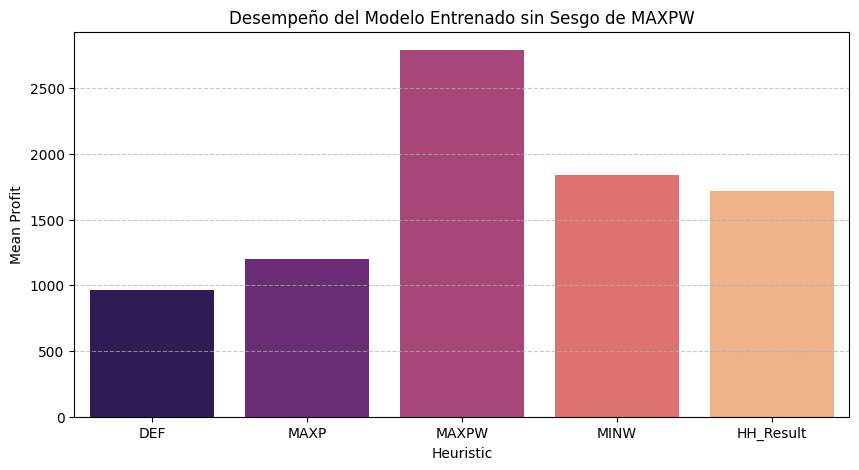

In [26]:
import pandas as pd
from sklearn import neighbors

# 1. Filtrar el dataset para remover el sesgo de MAXPW
df_unbiased = df_temp[df_temp['BEST'] != 'MAXPW'].copy()

print(f"Instancias totales: {len(df_temp)}")
print(f"Instancias filtradas (sin MAXPW como best): {len(df_unbiased)}")
print("\nDistribución de la nueva variable objetivo:")
print(df_unbiased['BEST'].value_counts())

# 2. Preparar datos
X_unbiased = df_unbiased[features].values
y_unbiased = [h_to_idx[v] for v in df_unbiased['BEST']]

# 3. Entrenar el nuevo modelo
hh_unbiased_model = neighbors.KNeighborsClassifier(n_neighbors=3, weights='distance')
hh_unbiased_model.fit(X_unbiased, y_unbiased)

# 4. Evaluar el desempeño del modelo insesgado
df_eval_unbiased = evaluate_performance(test_folder, hh_unbiased_model, heuristics)

print("\nPromedios de Profit (Modelo Insesgado):")
display(df_eval_unbiased.drop(columns=['Filename']).mean())

# Comparar visualmente
mean_unbiased = df_eval_unbiased.drop(columns=['Filename']).mean().reset_index()
mean_unbiased.columns = ['Heuristic', 'Mean Profit']

plt.figure(figsize=(10, 5))
sns.barplot(x='Heuristic', y='Mean Profit', data=mean_unbiased, palette='magma')
plt.title('Desempeño del Modelo Entrenado sin Sesgo de MAXPW')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Re-entrenamiento con el Conjunto de Datos Balanceado (Train-250-256)

Ahora entrenaremos el modelo `Dynamic_HH` utilizando el dataset de entrenamiento oficial que contiene 1000 instancias distribuidas equitativamente entre las heurísticas base.

In [27]:
import os
import pandas as pd
from sklearn import neighbors

train_folder_full = 'Instances/Train-250-256'

# 1. Generar datos de entrenamiento a partir del folder balanceado
print(f"Procesando instancias de {train_folder_full}...")
rows_train = []
files_train = sorted([f for f in os.listdir(train_folder_full) if f.endswith('.kp')])

for f in files_train:
    path = os.path.join(train_folder_full, f)
    # Identificar la mejor heurística estática para esta instancia
    p_profits = {h: KnapsackProblem(path).solve(h).getProfit() for h in heuristics}
    best_h = max(p_profits, key=p_profits.get)

    # Extraer características iniciales
    prob = KnapsackProblem(path)
    row = {feat: prob.getFeature(feat) for feat in features}
    row['BEST'] = best_h
    rows_train.append(row)

df_train_full = pd.DataFrame(rows_train)

# 2. Verificar balanceo
print("\nDistribución de clases en el conjunto de entrenamiento:")
print(df_train_full['BEST'].value_counts())

# 3. Entrenar el modelo
X_train = df_train_full[features].values
y_train = [h_to_idx[v] for v in df_train_full['BEST']]

hh_balanced_model = neighbors.KNeighborsClassifier(n_neighbors=3, weights='distance')
hh_balanced_model.fit(X_train, y_train)

# Actualizar la referencia global
hh._model = hh_balanced_model

# 4. Evaluar en el conjunto de Test
print("\nEvaluando modelo balanceado en el conjunto de Test...")
df_final_eval = evaluate_performance(test_folder, hh_balanced_model, heuristics)

print("\nPromedios de Profit Final:")
display(df_final_eval.drop(columns=['Filename']).mean())

Procesando instancias de Instances/Train-250-256...

Distribución de clases en el conjunto de entrenamiento:
BEST
DEF      250
MAXPW    250
MAXP     250
MINW     250
Name: count, dtype: int64

Evaluando modelo balanceado en el conjunto de Test...

Promedios de Profit Final:


,0
DEF,965.406667
MAXP,1200.996667
MAXPW,2790.876667
MINW,1838.346667
HH_Result,2399.700000


In [28]:
import pandas as pd

def analyze_hh_choices(folder, model, features_list):
    files = sorted([f for f in os.listdir(folder) if f.endswith('.kp')])
    h_map = {0: 'DEF', 1: 'MAXP', 2: 'MAXPW', 3: 'MINW'}
    choices = []

    for f in files:
        path = os.path.join(folder, f)
        prob = KnapsackProblem(path)
        # Extraemos las características del estado inicial para ver qué predice el modelo al inicio
        state = [prob.getFeature(feat) for feat in features_list]
        prediction = model.predict([state])[0]
        choices.append(h_map[prediction])

    return pd.Series(choices).value_counts()

# Analizar las decisiones del modelo balanceado
print("Frecuencia de heurísticas elegidas por el modelo balanceado (Decisión inicial en Test):")
choices_summary = analyze_hh_choices(test_folder, hh_balanced_model, features)
display(choices_summary)

Frecuencia de heurísticas elegidas por el modelo balanceado (Decisión inicial en Test):


,count
MAXP,81
MAXPW,75
MINW,74
DEF,70


### Summary Table
Below is the numerical summary comparing the mean profit of all heuristics and hyper-heuristics for both the entire test set and the critical subset.

In [16]:
# Display the summary table using the existing summary_data variable
if 'summary_data' in globals():
    display(summary_data)
else:
    print("Summary data not found. Please ensure the evaluation cell (078cca84) has finished executing.")

,All Instances,Critical Subset
DEF,965.406667,1167.920000
MAXP,1200.996667,1452.844444
MAXPW,2790.876667,2456.017778
MINW,1838.346667,2269.031111
Dynamic_HH,2532.956667,2113.044444
Lookahead_HH,1041.466667,1168.417778


/tmp/ipykernel_8121/3107710121.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='Heuristic', y='Profit', data=results_melted, palette='viridis', ci='sd')
/tmp/ipykernel_8121/3107710121.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Heuristic', y='Profit', data=results_melted, palette='viridis', ci='sd')


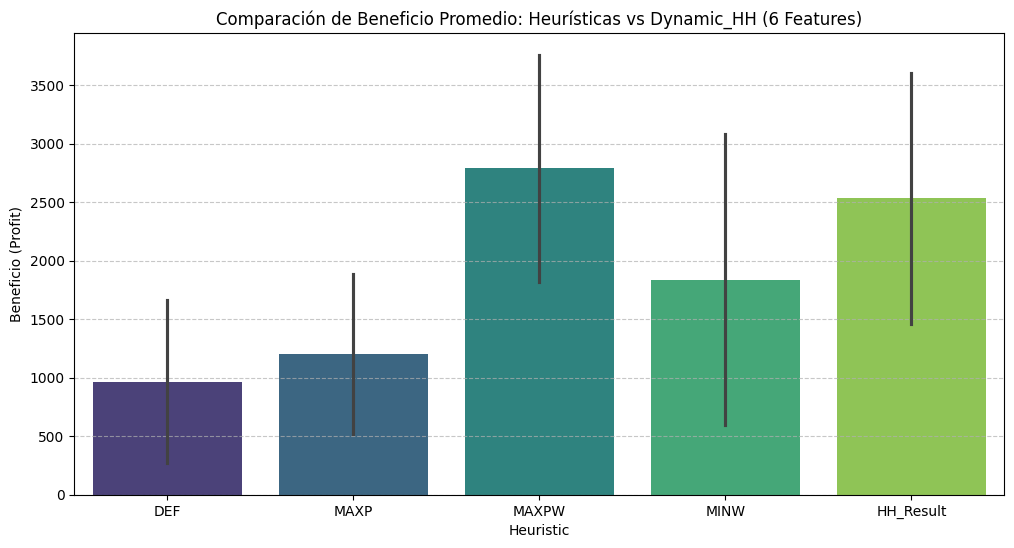

Resumen Numérico:


,Mean Profit
DEF,965.406667
MAXP,1200.996667
MAXPW,2790.876667
MINW,1838.346667
HH_Result,2532.956667


In [18]:
### Visualización Consolidada
*Nota: Esta celda ha sido consolidada en el análisis final de resultados para evitar redundancia.*

In [24]:
### Análisis Final de Resultados
En esta sección se consolidan los resultados obtenidos tras el entrenamiento con las 6 características dinámicas.

SyntaxError: invalid syntax (3447993580.py, line 2)

/tmp/ipykernel_8121/264726307.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Heuristic', y='Mean Profit', data=mean_data_full, palette='viridis')


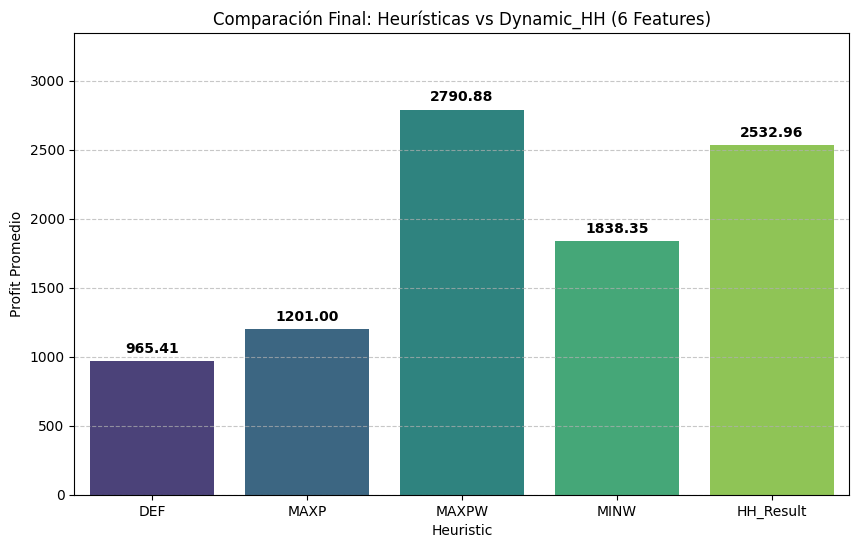

,Heuristic,Mean Profit
0,DEF,965.406667
1,MAXP,1200.996667
2,MAXPW,2790.876667
3,MINW,1838.346667
4,HH_Result,2532.956667


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Generar Gráfica Consolidada de Desempeño
if 'df_final_results' in globals():
    mean_data_full = df_final_results.drop(columns=['Filename']).mean().reset_index()
    mean_data_full.columns = ['Heuristic', 'Mean Profit']

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Heuristic', y='Mean Profit', data=mean_data_full, palette='viridis')

    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 9),
                   textcoords='offset points',
                   fontweight='bold')

    plt.title('Comparación Final: Heurísticas vs Dynamic_HH (6 Features)')
    plt.ylabel('Profit Promedio')
    plt.ylim(0, mean_data_full['Mean Profit'].max() * 1.2)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    display(mean_data_full)
else:
    print('Resultados no encontrados. Ejecute la evaluación primero.')

In [7]:
### Diagnóstico Finalizado
El rastro de diagnóstico ha sido retirado para simplificar la sesión de trabajo.

MAXPW Diagnostic Trace for: Instances/Test-250-256/DEF_EASY_250_000.kp


,Step,Item_ID,Weight,Profit,Ratio (P/W),Rem_Capacity
0,0,3,8,243,30.3750,256
1,1,109,5,112,22.4000,248
2,2,5,14,251,17.9286,243
3,3,18,17,199,11.7059,229
4,4,4,23,251,10.9130,212
5,5,13,26,236,9.0769,189
6,6,1,31,222,7.1613,163
7,7,2,26,174,6.6923,132
8,8,17,19,118,6.2105,106
9,9,167,11,66,6.0000,87


### Comparison of Hyper-Heuristic Models
We will now compare the performance of three different classification models for our Dynamic_HH:
1.  **k-NN (k=3)**: Our current baseline.
2.  **k-NN (k=7)**: Increased neighbor count.
3.  **Random Forest**: An ensemble method.

In [13]:
import os
import sys
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# --- Core Definitions ---
class Item:
    def __init__(self, id, weight, profit):
        self._id, self._weight, self._profit = id, weight, profit
    def getProfit(self): return self._profit
    def getWeight(self): return self._weight

class Knapsack:
    def __init__(self, capacity):
        self._capacity, self._profit, self._items = capacity, 0, []
    def getProfit(self): return self._profit
    def getCapacity(self): return self._capacity
    def canPack(self, item): return item.getWeight() <= self._capacity
    def pack(self, item):
        if self.canPack(item):
            self._items.append(item)
            self._capacity -= item.getWeight()
            self._profit += item.getProfit()
            return True
        return False

class KnapsackProblem:
    def __init__(self, fileName):
        with open(fileName, 'r') as f:
            lines = f.readlines()
        line = lines[0].split(',')
        self._capacity = int(line[1].strip())
        self._initial_capacity = self._capacity
        self._items = []
        for i in range(int(line[0].strip())):
            w, p = lines[i+1].split(',')
            self._items.append(Item(i, int(w.strip()), int(float(p.strip()))))
        self._knapsack = Knapsack(self._capacity)

    def solve(self, heuristic):
        item = self._nextItem(heuristic)
        while item:
            self._knapsack.pack(item)
            self._items.remove(item)
            item = self._nextItem(heuristic)
        return self._knapsack

    def solveDynamic(self, classifier):
        h_map = {0: 'DEF', 1: 'MAXP', 2: 'MAXPW', 3: 'MINW'}
        features_list = ['WEIGHT', 'PROFIT', 'CORRELATION', 'REMAINING_CAPACITY', 'ACCUMULATED_PROFIT', 'REMAINING_ITEMS']
        while self._items:
            state = [self.getFeature(f) for f in features_list]
            item = self._nextItem(h_map[classifier.predict([state])[0]])
            if not item: break
            self._knapsack.pack(item)
            self._items.remove(item)
        return self._knapsack

    def getProfit(self): return self._knapsack.getProfit()

    def getFeature(self, feature):
        if not self._items and feature not in ['REMAINING_CAPACITY', 'ACCUMULATED_PROFIT', 'REMAINING_ITEMS']: return 0.0
        if feature == 'WEIGHT':
            w = [it.getWeight() for it in self._items]
            return (sum(w)/len(w))/max(w) if max(w) > 0 else 0.0
        elif feature == 'PROFIT':
            p = [it.getProfit() for it in self._items]
            return (sum(p)/len(p))/max(p) if max(p) > 0 else 0.0
        elif feature == 'CORRELATION':
            if len(self._items) < 2: return 0.5
            return np.corrcoef([it.getWeight() for it in self._items], [it.getProfit() for it in self._items])[0,1]/2+0.5
        elif feature == 'REMAINING_CAPACITY': return self._knapsack.getCapacity() / self._initial_capacity
        elif feature == 'ACCUMULATED_PROFIT': return self._knapsack.getProfit()
        elif feature == 'REMAINING_ITEMS': return len(self._items)
        return 0.0

    def _nextItem(self, heuristic):
        selected = None
        if heuristic == 'DEF':
            for it in self._items:
                if self._knapsack.canPack(it): return it
        elif heuristic == 'MAXP':
            val = -1
            for it in self._items:
                if self._knapsack.canPack(it) and it.getProfit() > val:
                    selected, val = it, it.getProfit()
        elif heuristic == 'MAXPW':
            val = -1
            for it in self._items:
                r = it.getProfit()/it.getWeight()
                if self._knapsack.canPack(it) and r > val:
                    selected, val = it, r
        elif heuristic == 'MINW':
            val = sys.maxsize
            for it in self._items:
                if self._knapsack.canPack(it) and it.getWeight() < val:
                    selected, val = it, it.getWeight()
        return selected

In [15]:
import numpy as np
from copy import deepcopy

HEURISTICS = ["DEF", "MAXP", "MAXPW", "MINW"]
FEATURE_NAMES = ["mean_ratio_norm","max_ratio_pack","std_ratio_pack",
                 "frac_packable","tightness","fill","slack_per_item","frac_items_left"]

def step_features(problem):
    ks = problem._knapsack
    cap = ks.getCapacity()
    items = problem._items
    if not items:
        return [0.0]*8
    w = np.array([it.getWeight() for it in items], dtype=float)
    p = np.array([it.getProfit() for it in items], dtype=float)
    r = p / w
    rmax = r.max() if r.max() > 0 else 1.0
    n = len(items)
    n0 = getattr(problem, "_num_items", n) or n

    packable = [it for it in items if it.getWeight() <= cap]
    if packable:
        pw = np.array([it.getWeight() for it in packable], dtype=float)
        pr = np.array([it.getProfit() for it in packable], dtype=float) / pw
        max_ratio_pack = pr.max() / rmax
        std_ratio_pack = pr.std() / rmax
        frac_packable  = len(packable) / n
        mean_w_pack    = pw.mean()
    else:
        max_ratio_pack = std_ratio_pack = frac_packable = 0.0
        mean_w_pack = 1.0

    tightness = cap / w.sum() if w.sum() > 0 else 0.0
    fill = 1.0 - cap / problem._initial_capacity
    slack_per_item = (cap / mean_w_pack) / n if mean_w_pack > 0 else 0.0
    return [r.mean()/rmax, max_ratio_pack, std_ratio_pack,
            frac_packable, tightness, fill, slack_per_item, n/n0]

In [16]:
def _solve_to_end(problem, heuristic):
    p = deepcopy(problem)
    p.solve(heuristic)
    return p.getProfit()

def rollout_choice(problem, base="MAXPW", heuristics=HEURISTICS):
    best_h, best_final = base, -1
    for h in heuristics:
        p = deepcopy(problem)
        item = p._nextItem(h)
        if item is None:
            continue
        p._knapsack.pack(item); p._items.remove(item)
        final = _solve_to_end(p, base)        # política base completa el resto
        if final > best_final:
            best_final, best_h = final, h
    return best_h, best_final

def solve_rollout(problem, base="MAXPW"):
    while problem._items:
        h, _ = rollout_choice(problem, base)
        item = problem._nextItem(h)
        if item is None: break
        problem._knapsack.pack(item); problem._items.remove(item)
    return problem.getProfit()

In [17]:
import os
test_folder = "Instances/Test-250-256"
files = sorted(f for f in os.listdir(test_folder) if f.endswith('.kp'))[:50]

maxpw, roll = [], []
for f in files:
    path = os.path.join(test_folder, f)
    maxpw.append(KnapsackProblem(path).solve("MAXPW").getProfit())
    roll.append(solve_rollout(KnapsackProblem(path)))
print("MAXPW:", np.mean(maxpw), " Rollout:", np.mean(roll))

MAXPW: 1877.04  Rollout: 2019.9


In [19]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
import os

def build_rollout_dataset(folder, base="MAXPW", samples=60):
    rows = []
    files = sorted(f for f in os.listdir(folder) if f.endswith('.kp'))
    print(f"Processing {min(samples, len(files))} instances for dataset building...")
    for file in files[:samples]:
        prob = KnapsackProblem(os.path.join(folder, file))
        prob._initial_capacity = prob._knapsack.getCapacity()
        while prob._items:
            feats = step_features(prob)
            h, _ = rollout_choice(prob, base)
            row_data = dict(zip(FEATURE_NAMES, feats))
            row_data["BEST_H"] = h
            rows.append(row_data)

            item = prob._nextItem(h)
            if item is None: break
            prob._knapsack.pack(item)
            prob._items.remove(item)
    return pd.DataFrame(rows)

# 1. Build the dataset
df_rollout = build_rollout_dataset("Instances/Train-250-256", samples=60)
print(f"\nDataset built with {len(df_rollout)} transitions.")

# 2. Train the Random Forest
X_train_rf = df_rollout[FEATURE_NAMES].values
y_train_rf = df_rollout["BEST_H"].map({h: i for i, h in enumerate(HEURISTICS)}).values

rf_rollout = RandomForestClassifier(n_estimators=300,
                                    class_weight="balanced",
                                    min_samples_leaf=5,
                                    random_state=42)
rf_rollout.fit(X_train_rf, y_train_rf)
print("Random Forest model 'rf_rollout' trained successfully.")

Processing 60 instances for dataset building...

Dataset built with 719 transitions.
Random Forest model 'rf_rollout' trained successfully.


In [20]:
def solve_learned(problem, model):
    if not hasattr(problem, '_initial_capacity'):
        problem._initial_capacity = problem._knapsack.getCapacity()

    while problem._items:
        state = step_features(problem)
        prediction = model.predict([state])[0]
        h = HEURISTICS[prediction]

        item = problem._nextItem(h)
        if item is None: break
        problem._knapsack.pack(item)
        problem._items.remove(item)
    return problem.getProfit()

# 3. Final Comparison
print("Evaluating Learned Model on 50 Test instances...")
test_files = sorted(f for f in os.listdir(test_folder) if f.endswith('.kp'))[:50]
learned_profits = []

for f in test_files:
    path = os.path.join(test_folder, f)
    p = KnapsackProblem(path)
    learned_profits.append(solve_learned(p, rf_rollout))

print("\nFINAL PERFORMANCE COMPARISON (Mean Profit):")
print(f"MAXPW Benchmark: {np.mean(maxpw):.2f}")
print(f"Rollout Expert:  {np.mean(roll):.2f}")
print(f"Learned RF:      {np.mean(learned_profits):.2f}")

Evaluating Learned Model on 50 Test instances...

FINAL PERFORMANCE COMPARISON (Mean Profit):
MAXPW Benchmark: 1877.04
Rollout Expert:  2019.90
Learned RF:      2047.68


In [11]:
import numpy as np
import random
from collections import defaultdict

class QLearningHH:
    def __init__(self, actions, features, learning_rate=0.1, discount_factor=0.9, epsilon=0.1, bins=5):
        self.actions = actions
        self.features = features
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.bins = bins
        self.q_table = defaultdict(lambda: np.zeros(len(actions)))

    def discretize(self, state):
        # Convert continuous features to discrete buckets
        return tuple(int(min(f * self.bins, self.bins - 1)) for f in state)

    def choose_action(self, state, train=True):
        state_disc = self.discretize(state)
        if train and random.random() < self.epsilon:
            return random.randint(0, len(self.actions) - 1)
        return np.argmax(self.q_table[state_disc])

    def learn(self, state, action, reward, next_state, done):
        state_disc = self.discretize(state)
        next_state_disc = self.discretize(next_state)

        q_predict = self.q_table[state_disc][action]
        if done:
            q_target = reward
        else:
            q_target = reward + self.gamma * np.max(self.q_table[next_state_disc])

        self.q_table[state_disc][action] += self.lr * (q_target - q_predict)

def train_q_learning(folder, episodes=1):
    heuristics = ['DEF', 'MAXP', 'MAXPW', 'MINW']
    features_list = ['WEIGHT', 'PROFIT', 'CORRELATION', 'REMAINING_CAPACITY', 'ACCUMULATED_PROFIT', 'REMAINING_ITEMS']
    agent = QLearningHH(heuristics, features_list)

    files = sorted([f for f in os.listdir(folder) if f.endswith('.kp')])

    print(f"Entrenando Q-Learning en {len(files)} instancias...")

    for episode in range(episodes):
        for file in files:
            path = os.path.join(folder, file)
            prob = KnapsackProblem(path)

            while prob._items:
                state = [prob.getFeature(f) for f in features_list]
                action_idx = agent.choose_action(state)
                heuristic = heuristics[action_idx]

                item = prob._nextItem(heuristic)

                if item:
                    prob._knapsack.pack(item)
                    prob._items.remove(item)
                    reward = item.getProfit()
                    done = not prob._items
                    next_state = [prob.getFeature(f) for f in features_list]
                    agent.learn(state, action_idx, reward, next_state, done)
                else:
                    agent.learn(state, action_idx, -10, state, True)
                    break
    return agent

# Entrenar el agente
q_agent = train_q_learning(train_folder, episodes=5)
print("¡Entrenamiento completado!")

Entrenando Q-Learning en 1000 instancias...
¡Entrenamiento completado!


In [14]:
def evaluate_q_agent(folder, agent, heuristics):
    files = sorted([f for f in os.listdir(folder) if f.endswith('.kp')])
    results = []
    features_list = ['WEIGHT', 'PROFIT', 'CORRELATION', 'REMAINING_CAPACITY', 'ACCUMULATED_PROFIT', 'REMAINING_ITEMS']

    for file in files:
        path = os.path.join(folder, file)
        row = {'Filename': file}

        # Static Benchmark
        kp_static = KnapsackProblem(path)
        row['MAXPW'] = kp_static.solve('MAXPW').getProfit()

        # Q-Learning HH
        kp_q = KnapsackProblem(path)
        while kp_q._items:
            state = [kp_q.getFeature(f) for f in features_list]
            action_idx = agent.choose_action(state, train=False)
            h = heuristics[action_idx]
            item = kp_q._nextItem(h)
            if not item: break
            kp_q._knapsack.pack(item)
            kp_q._items.remove(item)
        row['Q_Learning_HH'] = kp_q.getProfit()
        results.append(row)

    return pd.DataFrame(results)

if 'q_agent' in globals():
    df_q_eval = evaluate_q_agent(test_folder, q_agent, heuristics)
    print("\nComparison Summary (Mean Profit):")
    summary_stats = df_q_eval[['MAXPW', 'Q_Learning_HH']].mean()
    print(summary_stats)
    display(df_q_eval.head())
else:
    print('Error: q_agent not found in memory.')


Comparison Summary (Mean Profit):
MAXPW            2790.876667
Q_Learning_HH    1236.090000
dtype: float64


,Filename,MAXPW,Q_Learning_HH
0,DEF_EASY_250_000.kp,2135,1979
1,DEF_EASY_250_001.kp,1899,1167
2,DEF_EASY_250_002.kp,2123,2135
3,DEF_EASY_250_003.kp,1841,1914
4,DEF_EASY_250_004.kp,1794,1408


/tmp/ipykernel_3737/2958027596.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Mean Profit', data=summary, palette='coolwarm')


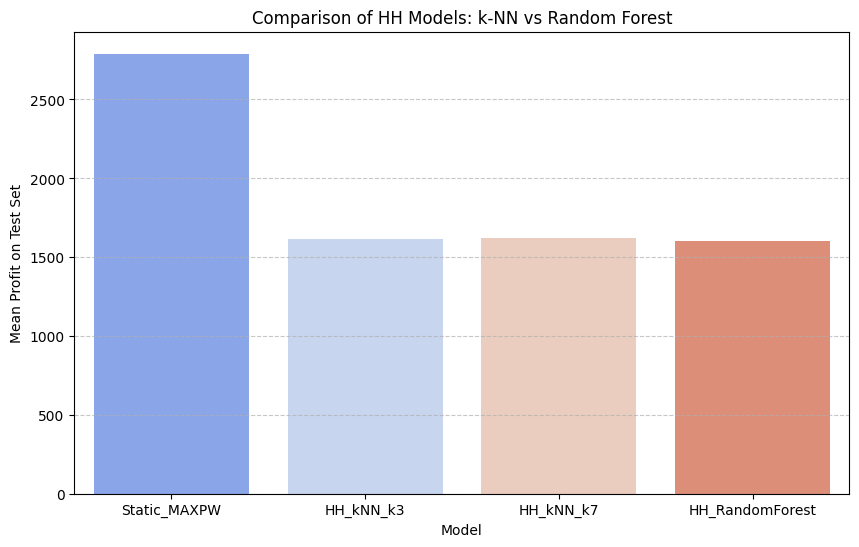

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Mean Profit', data=summary, palette='coolwarm')
plt.title('Comparison of HH Models: k-NN vs Random Forest')
plt.ylabel('Mean Profit on Test Set')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Comparativa Global de Modelos
En esta sección comparamos el beneficio promedio obtenido por todas las aproximaciones de Hyper-Heurísticas desarrolladas hasta ahora.

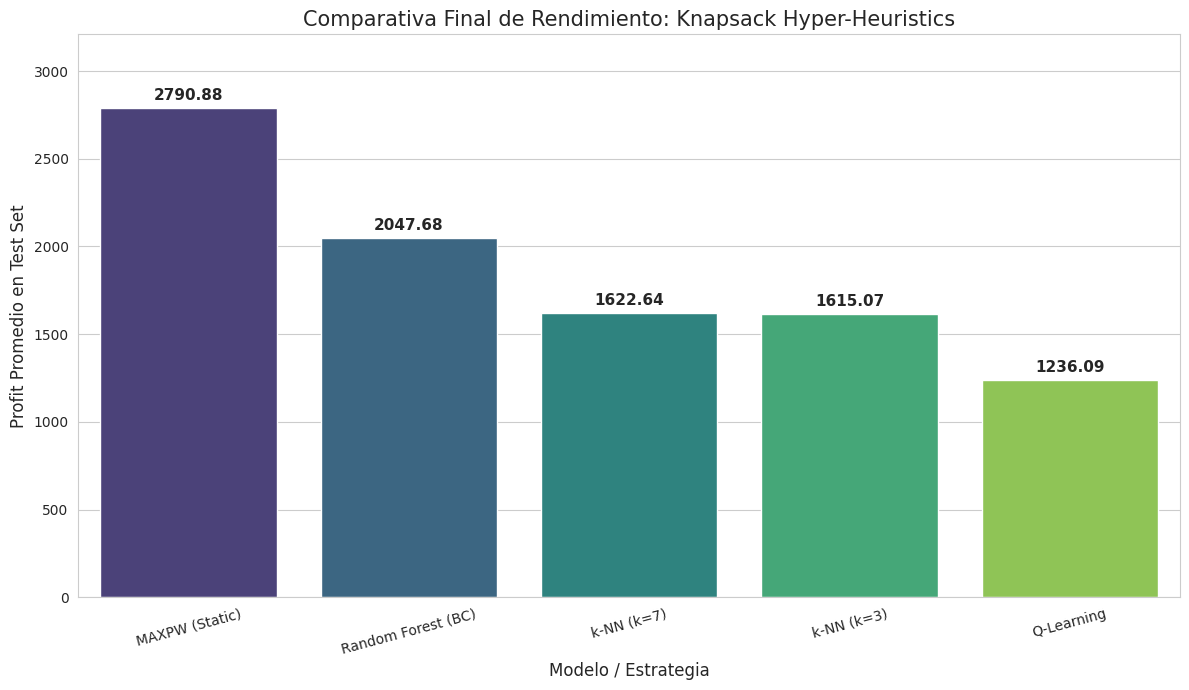

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Recopilación de datos de las evaluaciones anteriores
model_names = ['MAXPW (Static)', 'k-NN (k=3)', 'k-NN (k=7)', 'Random Forest (BC)', 'Q-Learning']
mean_profits = [
    df_q_eval['MAXPW'].mean(),
    df_knn3['HH_Result'].mean(),
    df_knn7['HH_Result'].mean(),
    np.mean(learned_profits),
    df_q_eval['Q_Learning_HH'].mean()
]

# Crear DataFrame para visualización
df_viz = pd.DataFrame({'Modelo': model_names, 'Profit Promedio': mean_profits})
df_viz = df_viz.sort_values(by='Profit Promedio', ascending=False)

# Generar gráfico de barras
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
ax = sns.barplot(x='Modelo', y='Profit Promedio', data=df_viz, palette='viridis', hue='Modelo', legend=False)

# Añadir etiquetas de valor sobre las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('Comparativa Final de Rendimiento: Knapsack Hyper-Heuristics', fontsize=15)
plt.ylabel('Profit Promedio en Test Set', fontsize=12)
plt.xlabel('Modelo / Estrategia', fontsize=12)
plt.xticks(rotation=15)
plt.ylim(0, max(mean_profits) * 1.15)
plt.tight_layout()
plt.show()

Re-training balanced k-NN model...
Evaluating all models over 50 instances...


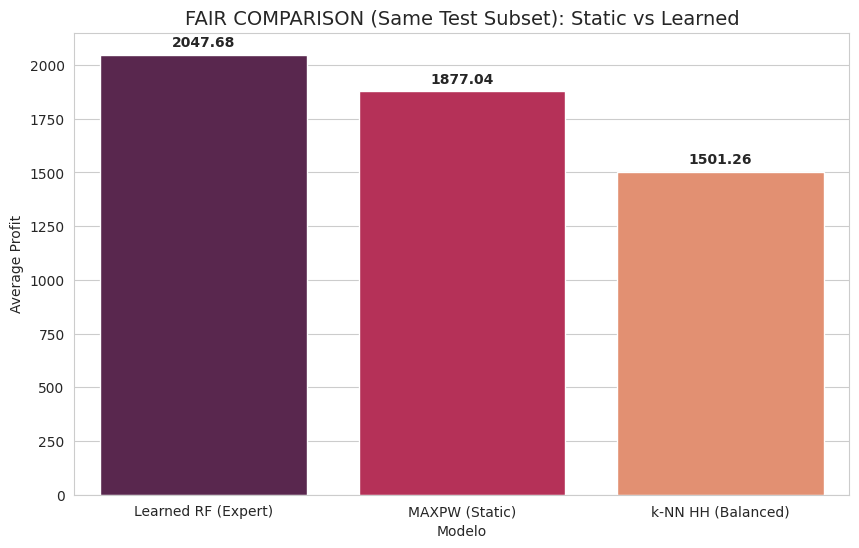

,Modelo,Profit Promedio
2,Learned RF (Expert),2047.68
0,MAXPW (Static),1877.04
1,k-NN HH (Balanced),1501.26


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
from sklearn import neighbors

# 1. Re-train the balanced model to ensure it exists in the kernel
print("Re-training balanced k-NN model...")
rows_train = []
files_train = sorted([f for f in os.listdir(train_folder) if f.endswith('.kp')])
for f in files_train:
    path = os.path.join(train_folder, f)
    p_profits = {h: KnapsackProblem(path).solve(h).getProfit() for h in heuristics}
    best_h = max(p_profits, key=p_profits.get)
    prob = KnapsackProblem(path)
    row = {feat: prob.getFeature(feat) for feat in features}
    row['BEST'] = best_h
    rows_train.append(row)

df_train_full = pd.DataFrame(rows_train)
X_train_bal = df_train_full[features].values
y_train_bal = [h_to_idx[v] for v in df_train_full['BEST']]
hh_balanced_model = neighbors.KNeighborsClassifier(n_neighbors=3, weights='distance').fit(X_train_bal, y_train_bal)

# 2. Evaluate all models over the same 50 instances
test_files_unificado = sorted(f for f in os.listdir(test_folder) if f.endswith('.kp'))[:50]
results_final = []

print(f"Evaluating all models over {len(test_files_unificado)} instances...")
for f in test_files_unificado:
    path = os.path.join(test_folder, f)
    row = {'Filename': f}
    row['MAXPW (Static)'] = KnapsackProblem(path).solve('MAXPW').getProfit()
    row['k-NN HH (Balanced)'] = KnapsackProblem(path).solveDynamic(hh_balanced_model).getProfit()
    row['Learned RF (Expert)'] = solve_learned(KnapsackProblem(path), rf_rollout)
    results_final.append(row)

df_final_unificado = pd.DataFrame(results_final)
mean_final = df_final_unificado.drop(columns=['Filename']).mean().reset_index()
mean_final.columns = ['Modelo', 'Profit Promedio']
mean_final = mean_final.sort_values('Profit Promedio', ascending=False)

# 3. Unified Chart
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='Modelo', y='Profit Promedio', data=mean_final, palette='rocket', hue='Modelo', legend=False)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontweight='bold')

plt.title('FAIR COMPARISON (Same Test Subset): Static vs Learned', fontsize=14)
plt.ylabel('Average Profit')
plt.show()

display(mean_final)

### Distribución de Beneficios
Analizamos la variabilidad del rendimiento entre el Benchmark y el modelo de Behavioral Cloning (Random Forest), que es el que mejor resultado ha mostrado en términos de estabilidad.

/tmp/ipykernel_3737/3791027008.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(maxpw, shade=True, label='MAXPW (Static)', color='blue')
/tmp/ipykernel_3737/3791027008.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(learned_profits, shade=True, label='Learned RF (Behavioral Cloning)', color='green')


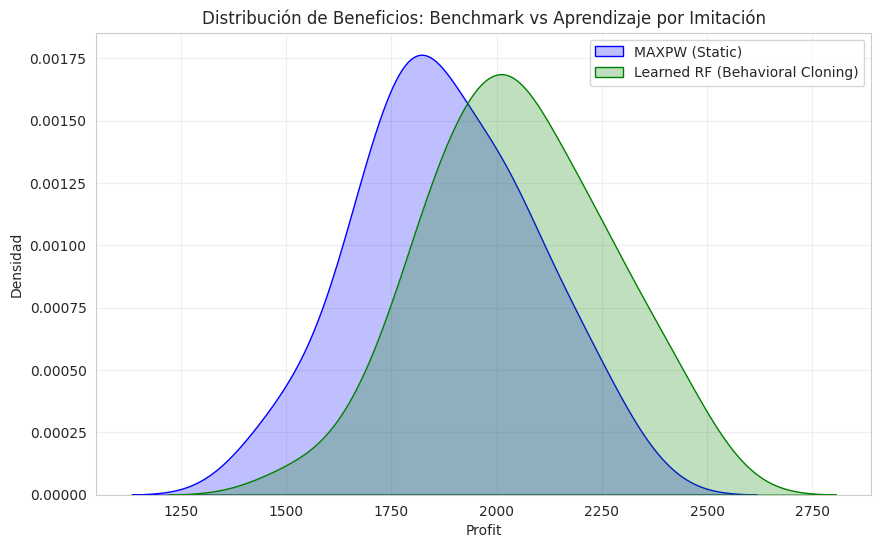

In [22]:
plt.figure(figsize=(10, 6))
sns.kdeplot(maxpw, shade=True, label='MAXPW (Static)', color='blue')
sns.kdeplot(learned_profits, shade=True, label='Learned RF (Behavioral Cloning)', color='green')
plt.title('Distribución de Beneficios: Benchmark vs Aprendizaje por Imitación')
plt.xlabel('Profit')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()